In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Setup
PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'
sys.path.insert(0, str(SRC_PATH))

from utils import set_random_seed
from plotting import DataPlotter

from config import CONFIG
set_random_seed(42)
plotter = DataPlotter()

print("✓ Setup complete!")

INFO:root:Random seed set to 42


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Setup complete!


In [23]:
nn_path = Path(CONFIG['evaluation_dir']) / 'nn_model_evaluation_results.json'
with open(nn_path) as f:
    nn_results = json.load(f)

xgb_path = Path(CONFIG['evaluation_dir']) / 'xgb_evaluation_results.json'
with open(xgb_path) as f:
    xgb_results = json.load(f)

print("\nNeural Network Results:")
print(json.dumps(nn_results, indent=2))

print("\n\nXGBoost Results:")
print(json.dumps(xgb_results, indent=2))


Neural Network Results:
{
  "model": "Neural Network",
  "auc": 0.7417328357901984,
  "brier_score": 0.2562,
  "log_loss": 9.234383998291815,
  "optimal_threshold": 0.001,
  "ams": 59.36170812290533,
  "tp": 4142,
  "fp": 1311,
  "tn": 3296,
  "fn": 1251,
  "accuracy": 0.7438,
  "precision": 0.759581881533101,
  "recall": 0.7680326348970888,
  "sensitivity": 0.7680326348970888,
  "specificity": 0.715433036683308,
  "f1_score": 0.7637838834593399,
  "matthews_corrcoef": 0.48396029503506705,
  "false_positive_rate": 0.284566963316692,
  "false_negative_rate": 0.2319673651029112,
  "total_samples": 10000
}


XGBoost Results:
{
  "model": "XGBoost",
  "auc": 0.8094430065165389,
  "brier_score": 0.17811934649944305,
  "log_loss": 0.5300871729850769,
  "optimal_threshold": 0.788,
  "ams": 72.31107288652295,
  "tp": 1752,
  "fp": 158,
  "tn": 4449,
  "fn": 3641,
  "accuracy": 0.6201,
  "precision": 0.9172774869109948,
  "recall": 0.32486556647506026,
  "sensitivity": 0.32486556647506026,
  "

In [26]:
comparison_data = []
comparison_data.append(nn_results)
comparison_data.append(xgb_results)


comparison_data = [
    {
        'Model': 'Neural Network',
        'AUC': nn_results['auc'],
        'Brier Score': nn_results['brier_score'],
        'Log Loss': nn_results['log_loss'],
        'Optimal Threshold': nn_results['optimal_threshold'],
        'AMS': nn_results['ams'],
        'Accuracy': nn_results['accuracy'],
        'Precision': nn_results['precision'],
        'Recall': nn_results['recall'],
        'F1 Score': nn_results['f1_score'],
        'TP': nn_results['tp'],
        'FP': nn_results['fp'],
        'TN': nn_results['tn'],
        'FN': nn_results['fn'],
    },
    {
        'Model': 'XGBoost',
        'AUC': xgb_results['auc'],
        'Brier Score': xgb_results['brier_score'],
        'Log Loss': xgb_results['log_loss'],
        'Optimal Threshold': xgb_results['optimal_threshold'],
        'AMS': xgb_results['ams'],
        'Accuracy': xgb_results['accuracy'],
        'Precision': xgb_results['precision'],
        'Recall': xgb_results['recall'],
        'F1 Score': xgb_results['f1_score'],
        'TP': xgb_results['tp'],
        'FP': xgb_results['fp'],
        'TN': xgb_results['tn'],
        'FN': xgb_results['fn'],
    }
]
comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,AUC,Brier Score,Log Loss,Optimal Threshold,AMS,Accuracy,Precision,Recall,F1 Score,TP,FP,TN,FN
0,Neural Network,0.741733,0.256200,9.234384,0.001,59.361708,0.7438,0.759582,0.768033,0.763784,4142,1311,3296,1251
1,XGBoost,0.809443,0.178119,0.530087,0.788,72.311073,0.6201,0.917277,0.324866,0.479803,1752,158,4449,3641


In [27]:
key_metrics_df = comparison_df[['Model', 'AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AMS']].copy()

print("\n" + "="*80)
print("KEY METRICS SUMMARY")
print("="*80)
print(key_metrics_df.to_string(index=False))
print("="*80)

# Highlight winner for each metric
print("\n🏆 METRIC WINNERS:")
for metric in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AMS']:
    nn_val = nn_results[metric.lower().replace(' ', '_')]
    xgb_val = xgb_results[metric.lower().replace(' ', '_')]
    
    if nn_val > xgb_val:
        winner = "Neural Network ✓"
        diff = nn_val - xgb_val
    else:
        winner = "XGBoost ✓"
        diff = xgb_val - nn_val
    
    print(f"  {metric:12} | NN: {nn_val:.4f} vs XGB: {xgb_val:.4f} | Winner: {winner} (+{diff:.4f})")


KEY METRICS SUMMARY
         Model      AUC  Accuracy  Precision   Recall  F1 Score       AMS
Neural Network 0.741733    0.7438   0.759582 0.768033  0.763784 59.361708
       XGBoost 0.809443    0.6201   0.917277 0.324866  0.479803 72.311073

🏆 METRIC WINNERS:
  AUC          | NN: 0.7417 vs XGB: 0.8094 | Winner: XGBoost ✓ (+0.0677)
  Accuracy     | NN: 0.7438 vs XGB: 0.6201 | Winner: Neural Network ✓ (+0.1237)
  Precision    | NN: 0.7596 vs XGB: 0.9173 | Winner: XGBoost ✓ (+0.1577)
  Recall       | NN: 0.7680 vs XGB: 0.3249 | Winner: Neural Network ✓ (+0.4432)
  F1 Score     | NN: 0.7638 vs XGB: 0.4798 | Winner: Neural Network ✓ (+0.2840)
  AMS          | NN: 59.3617 vs XGB: 72.3111 | Winner: XGBoost ✓ (+12.9494)


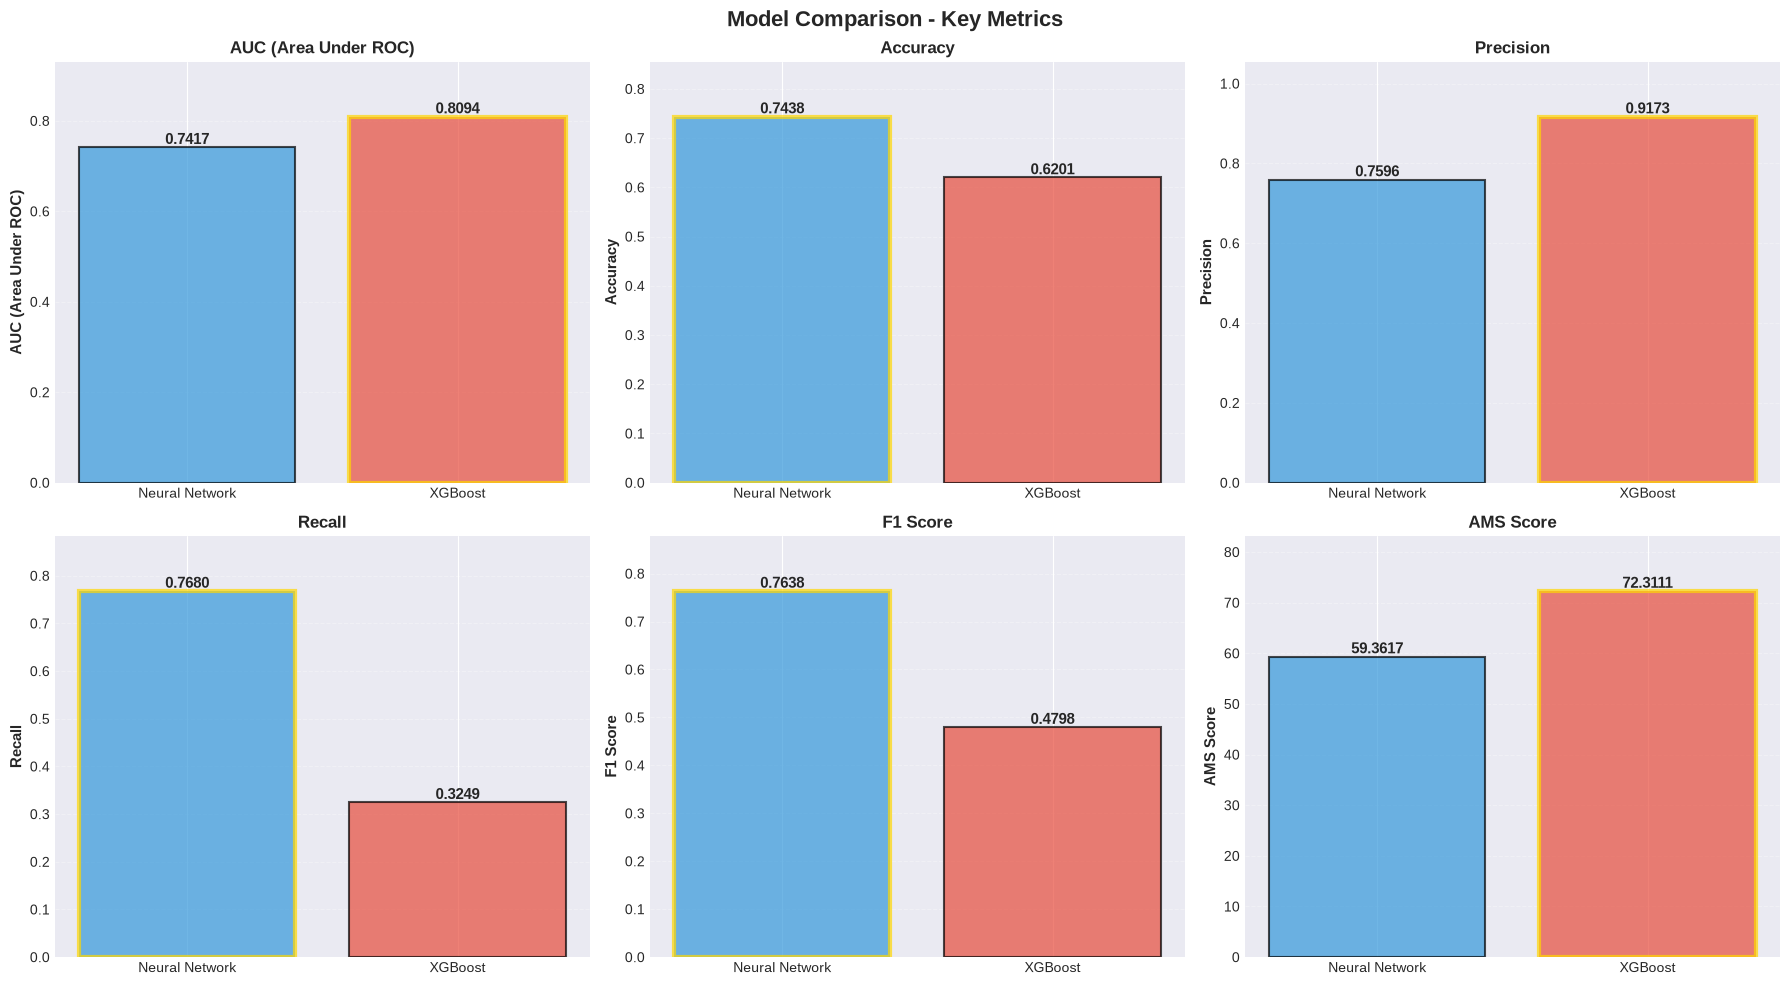

✓ Saved: 03_metrics_comparison.png


In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Comparison - Key Metrics', fontsize=16, fontweight='bold')

metrics = [
    ('auc', 'AUC (Area Under ROC)'),
    ('accuracy', 'Accuracy'),
    ('precision', 'Precision'),
    ('recall', 'Recall'),
    ('f1_score', 'F1 Score'),
    ('ams', 'AMS Score'),
]

for idx, (metric_key, metric_label) in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    models = ['Neural Network', 'XGBoost']
    values = [nn_results[metric_key], xgb_results[metric_key]]
    colors = ['#3498db', '#e74c3c']
    
    bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_ylabel(metric_label, fontsize=11, fontweight='bold')
    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(values) * 1.15])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Highlight winner
    winner_idx = np.argmax(values)
    bars[winner_idx].set_edgecolor('gold')
    bars[winner_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig(Path(CONFIG['plot_dir']) / '03_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_metrics_comparison.png")

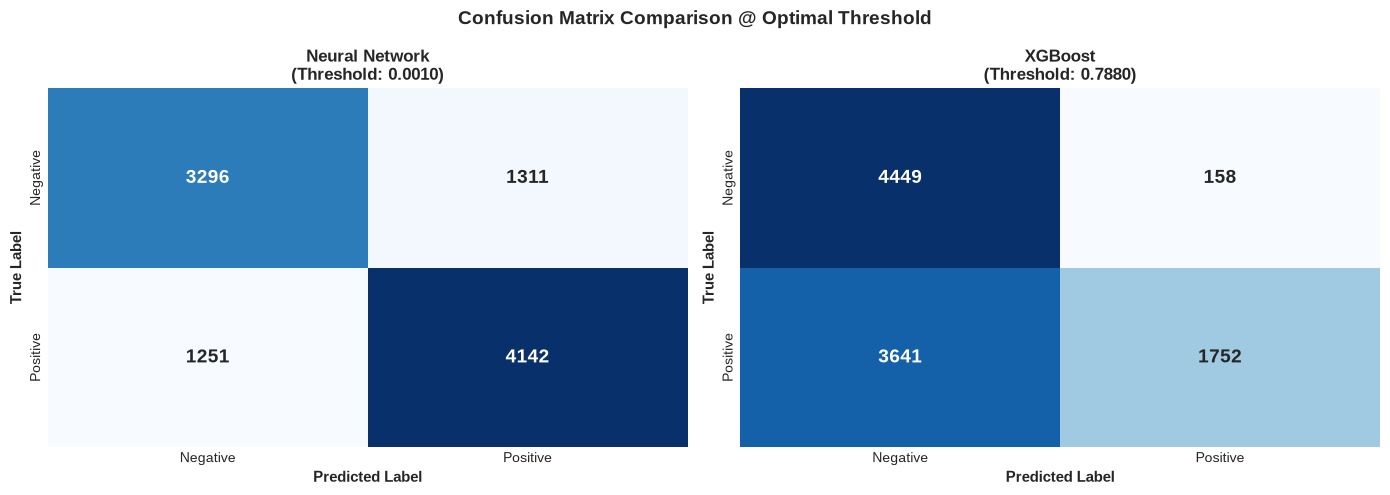

✓ Saved: 03_confusion_matrices.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix Comparison @ Optimal Threshold', fontsize=14, fontweight='bold')

models_data = [
    ('Neural Network', nn_results),
    ('XGBoost', xgb_results)
]

for ax, (model_name, results) in zip(axes, models_data):
    cm = np.array([
        [results['tn'], results['fp']],
        [results['fn'], results['tp']]
    ])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}\n(Threshold: {results["optimal_threshold"]:.4f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(Path(CONFIG['plot_dir']) / '03_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_confusion_matrices.png")

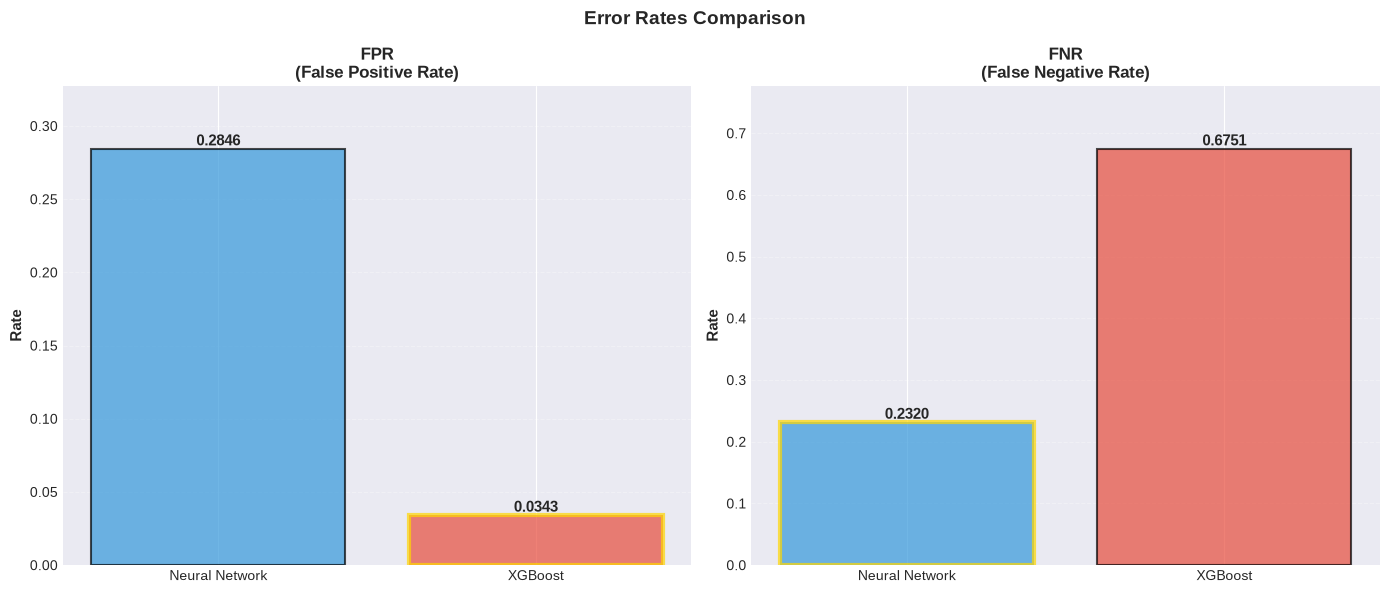

✓ Saved: 03_error_rates.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Error Rates Comparison', fontsize=14, fontweight='bold')

# Error rates
error_rates = {
    'FPR\n(False Positive Rate)': [nn_results['false_positive_rate'], xgb_results['false_positive_rate']],
    'FNR\n(False Negative Rate)': [nn_results['false_negative_rate'], xgb_results['false_negative_rate']],
}

for idx, (error_name, values) in enumerate(error_rates.items()):
    ax = axes[idx]
    models = ['Neural Network', 'XGBoost']
    colors = ['#3498db', '#e74c3c']
    
    bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_ylabel('Rate', fontsize=11, fontweight='bold')
    ax.set_title(error_name, fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(values) * 1.15])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Lower is better for error rates
    winner_idx = np.argmin(values)
    bars[winner_idx].set_edgecolor('gold')
    bars[winner_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig(Path(CONFIG['plot_dir']) / '03_error_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_error_rates.png")

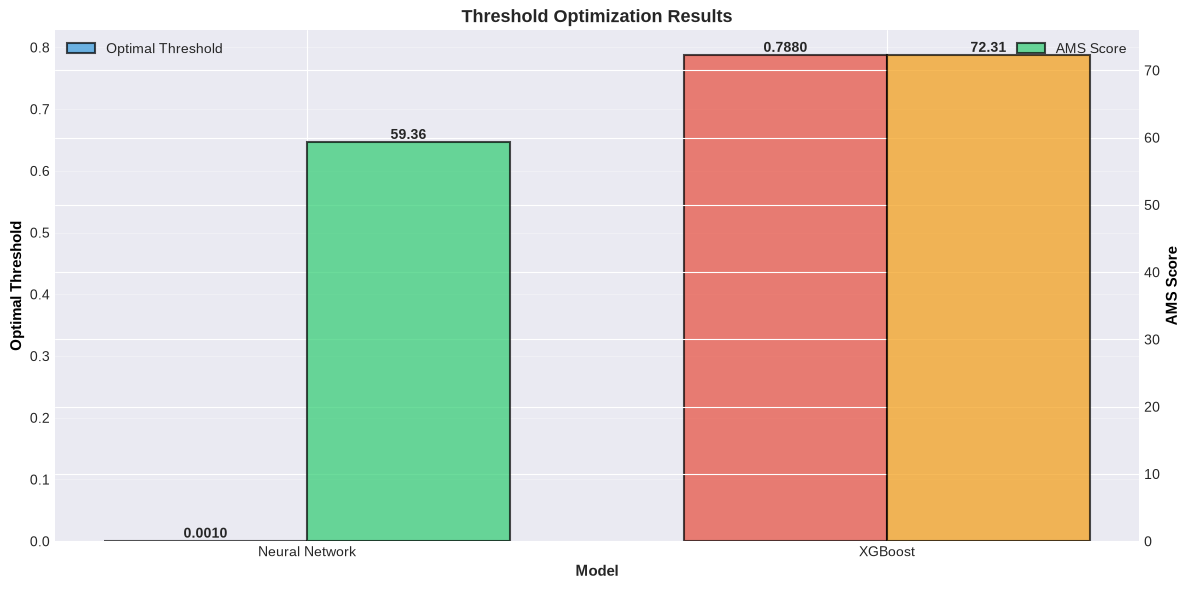

✓ Saved: 03_threshold_analysis.png


In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

models = ['Neural Network', 'XGBoost']
thresholds = [nn_results['optimal_threshold'], xgb_results['optimal_threshold']]
ams_scores = [nn_results['ams'], xgb_results['ams']]

colors = ['#3498db', '#e74c3c']
x_pos = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x_pos - width/2, thresholds, width, label='Optimal Threshold', 
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2 = ax.twinx()
bars2 = ax2.bar(x_pos + width/2, ams_scores, width, label='AMS Score',
                color=['#2ecc71', '#f39c12'], alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Optimal Threshold', fontsize=11, fontweight='bold', color='black')
ax2.set_ylabel('AMS Score', fontsize=11, fontweight='bold', color='black')
ax.set_title('Threshold Optimization Results', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars1, thresholds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

for bar, val in zip(bars2, ams_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add legends
ax.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(Path(CONFIG['plot_dir']) / '03_threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_threshold_analysis.png")